In [11]:
#References: lecture slides for jacobi and gauss seidel methods
#References: chatgpt, asked how to save error on python, asked if I should add one since no error at 0, to title plot.

import numpy as np
def jacobi(A, b, x0, tol=1e-6, max_iterations=100):
    n = len(b)
    x = x0.copy()
    error = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # save error which is absolute change between iterations
        e = np.linalg.norm(x_new - x, ord=np.inf)
        error.append(e)
        if e < tol:
            return x_new, (k + 1), np.array(error)
        x = x_new
    return x, max_iterations, np.array(error)

In [12]:
import numpy as np
def gauss_seidel(A, b, x0, tol=1e-6, max_iterations=100):
    n = len(b)
    x = x0.copy()
    error = []
    for k in range(max_iterations):
        x_old = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x[j]     for j in range(i))       # updated values
            s2 = sum(A[i][j] * x_old[j] for j in range(i+1, n))  # old values
            x[i] = (b[i] - s1 - s2) / A[i][i]
        # save error (absolute change between iterations)
        e = np.linalg.norm(x - x_old, ord=np.inf)
        error.append(e)
        if e < tol:
            return x, (k + 1), np.array(error)
    return x, max_iterations, np.array(error)

In [13]:
import numpy as np
A = np.array([
    [3.0,  -0.1, -0.2],
    [0.1,   7.0, -0.3],
    [0.3,  -0.2, 10.0]
], dtype=float)
b = np.array([7.85, -19.3, 71.4], dtype=float)
x0 = np.zeros_like(b, dtype=float)

tol=1e-9: solution= [ 3.  -2.5  7. ] , iterations= 9
tol=1e-6: solution= [ 3.  -2.5  7. ] , iterations= 7
tol=1e-3: solution= [ 3.0000225  -2.50000266  6.99998104] , iterations= 4


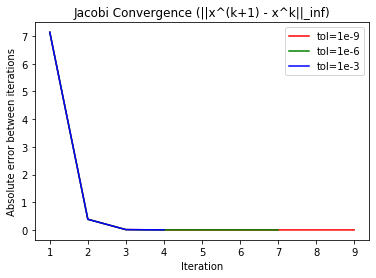

In [14]:
import matplotlib.pyplot as plt

# tol = 1e-9
solution, iterations, error = jacobi(A, b, x0, tol=1e-9, max_iterations=1000)
print("tol=1e-9:", "solution=", solution, ", iterations=", iterations)
plt.plot(np.arange(1, len(error)+1), error, 'r', label="tol=1e-9")

# tol = 1e-6
solution, iterations, error = jacobi(A, b, x0, tol=1e-6, max_iterations=1000)
print("tol=1e-6:", "solution=", solution, ", iterations=", iterations)
plt.plot(np.arange(1, len(error)+1), error, 'g', label="tol=1e-6")

# tol = 1e-3
solution, iterations, error = jacobi(A, b, x0, tol=1e-3, max_iterations=1000)
print("tol=1e-3:", "solution=", solution, ", iterations=", iterations)
plt.plot(np.arange(1, len(error)+1), error, 'b', label="tol=1e-3")

plt.title("Jacobi Convergence (||x^(k+1) - x^k||_inf)")
plt.xlabel("Iteration")
plt.ylabel("Absolute error between iterations")
plt.legend()
plt.show()

tol=1e-9: solution= [ 3.  -2.5  7. ] , iterations= 7
tol=1e-6: solution= [ 3.  -2.5  7. ] , iterations= 5
tol=1e-3: solution= [ 3.00000035 -2.50000004  6.99999999] , iterations= 4


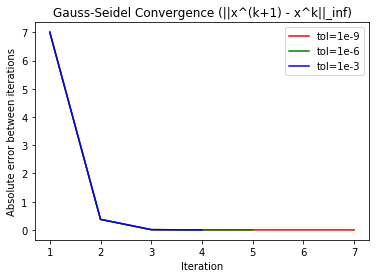

In [15]:
import matplotlib.pyplot as plt

# tol = 1e-9
solution, iterations, error = gauss_seidel(A, b, x0, tol=1e-9, max_iterations=1000)
print("tol=1e-9:", "solution=", solution, ", iterations=", iterations)
plt.plot(np.arange(1, len(error)+1), error, 'r', label="tol=1e-9")

# tol = 1e-6
solution, iterations, error = gauss_seidel(A, b, x0, tol=1e-6, max_iterations=1000)
print("tol=1e-6:", "solution=", solution, ", iterations=", iterations)
plt.plot(np.arange(1, len(error)+1), error, 'g', label="tol=1e-6")

# tol = 1e-3
solution, iterations, error = gauss_seidel(A, b, x0, tol=1e-3, max_iterations=1000)
print("tol=1e-3:", "solution=", solution, ", iterations=", iterations)
plt.plot(np.arange(1, len(error)+1), error, 'b', label="tol=1e-3")

plt.title("Gauss-Seidel Convergence (||x^(k+1) - x^k||_inf)")
plt.xlabel("Iteration")
plt.ylabel("Absolute error between iterations")
plt.legend()
plt.show()


In [16]:
#discussion:
"""
When the tolerance becomes smaller, the number of iterations greatens 
for both Jacobi and Gauss–Seidel methods. This is because a smaller 
tolerance means we are asking for a more precise solution, so the 
algorithm must continue iterating until the changes between the steps are 
very small. The Gauss–Seidel requires fewer iterations than 
Jacobi to reach the same tolerance. This is because Gauss–Seidel updates 
and uses new values during each iteration bascially instantly, which helps it 
converge faster. Jacobi on the otherhand uses only values from the previous
iteration, so it usually converges more slowly.
"""

'\nWhen the tolerance becomes smaller, the number of iterations greatens \nfor both Jacobi and Gauss–Seidel methods. This is because a smaller \ntolerance means we are asking for a more precise solution, so the \nalgorithm must continue iterating until the changes between the steps are \nvery small. The Gauss–Seidel requires fewer iterations than \nJacobi to reach the same tolerance. This is because Gauss–Seidel updates \nand uses new values during each iteration bascially instantly, which helps it \nconverge faster. Jacobi on the otherhand uses only values from the previous\niteration, so it usually converges more slowly.\n'